# Telco Customer Churn — Feature engineering and Preprocessing

This notebook prepares the cleaned Telco Customer Churn dataset for machine learning models.
The main goal is to review engineered features, define the target variable, split the data, encode categorical variables, and scale numerical variables when needed.

## 0. Import clean dataset

In [1]:
import pandas as pd

df = pd.read_csv("telco_churn_clean.csv")
df.head()

,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,online_backup,...,monthly_charges,total_charges,churn_flag,tenure_group,has_internet_service,has_fiber_optic,has_automatic_payment,service_count,customer_value,high_monthly_charges
0,Female,No,Yes,No,1,No,No,DSL,No,Yes,...,29.85,29.85,0,0_12_months,Yes,No,No,1,29.85,No
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,...,56.95,1889.50,0,25_48_months,Yes,No,No,3,1936.30,No
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,53.85,108.15,1,0_12_months,Yes,No,No,3,107.70,No
3,Male,No,No,No,45,No,No,DSL,Yes,No,...,42.30,1840.75,0,25_48_months,Yes,No,Yes,3,1903.50,No
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,...,70.70,151.65,1,0_12_months,Yes,Yes,No,1,141.40,Yes


## 1. Review clean dataset

In [2]:
df.shape

(7043, 27)

In [3]:
df.duplicated().sum()

np.int64(22)

### Duplicate Check

We identified 22 duplicated observations after removing the unique customer identifier (`customer_id`). Since the original dataset contained unique customer IDs, these duplicates most likely correspond to different customers sharing identical characteristics rather than data quality issues. Therefore, the duplicated rows were retained.

In [4]:
duplicates = df[df.duplicated(keep=False)]

duplicates.sort_values(list(df.columns)).head(30)

,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,online_backup,...,monthly_charges,total_charges,churn_flag,tenure_group,has_internet_service,has_fiber_optic,has_automatic_payment,service_count,customer_value,high_monthly_charges
6491,Female,No,No,No,1,Yes,No,Fiber optic,No,No,...,69.20,69.20,1,0_12_months,Yes,Yes,No,1,69.20,No
6764,Female,No,No,No,1,Yes,No,Fiber optic,No,No,...,69.20,69.20,1,0_12_months,Yes,Yes,No,1,69.20,No
4495,Female,No,No,No,1,Yes,No,Fiber optic,No,No,...,70.10,70.10,1,0_12_months,Yes,Yes,No,1,70.10,No
6267,Female,No,No,No,1,Yes,No,Fiber optic,No,No,...,70.10,70.10,1,0_12_months,Yes,Yes,No,1,70.10,No
5522,Female,No,No,No,1,Yes,No,Fiber optic,No,No,...,70.15,70.15,1,0_12_months,Yes,Yes,No,1,70.15,No
5759,Female,No,No,No,1,Yes,No,Fiber optic,No,No,...,70.15,70.15,1,0_12_months,Yes,Yes,No,1,70.15,No
542,Female,No,No,No,1,Yes,No,No,No,No,...,19.55,19.55,0,0_12_months,No,No,No,1,19.55,No
1491,Female,No,No,No,1,Yes,No,No,No,No,...,19.55,19.55,0,0_12_months,No,No,No,1,19.55,No
5170,Female,No,No,No,1,Yes,No,No,No,No,...,19.65,19.65,0,0_12_months,No,No,No,1,19.65,No
6774,Female,No,No,No,1,Yes,No,No,No,No,...,19.65,19.65,0,0_12_months,No,No,No,1,19.65,No


In [5]:
duplicates.groupby(list(df.columns)).size().reset_index(name="count").sort_values("count", ascending=False)

,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,online_backup,...,total_charges,churn_flag,tenure_group,has_internet_service,has_fiber_optic,has_automatic_payment,service_count,customer_value,high_monthly_charges,count
12,Male,No,No,No,1,Yes,No,No,No,No,...,20.05,0,0_12_months,No,No,No,1,20.05,No,3
14,Male,No,No,No,1,Yes,No,No,No,No,...,20.20,0,0_12_months,No,No,No,1,20.20,No,3
0,Female,No,No,No,1,Yes,No,Fiber optic,No,No,...,69.20,1,0_12_months,Yes,Yes,No,1,69.20,No,2
1,Female,No,No,No,1,Yes,No,Fiber optic,No,No,...,70.10,1,0_12_months,Yes,Yes,No,1,70.10,No,2
3,Female,No,No,No,1,Yes,No,No,No,No,...,19.55,0,0_12_months,No,No,No,1,19.55,No,2
2,Female,No,No,No,1,Yes,No,Fiber optic,No,No,...,70.15,1,0_12_months,Yes,Yes,No,1,70.15,No,2
4,Female,No,No,No,1,Yes,No,No,No,No,...,19.65,0,0_12_months,No,No,No,1,19.65,No,2
5,Female,No,No,No,1,Yes,No,No,No,No,...,19.90,0,0_12_months,No,No,No,1,19.90,No,2
8,Male,No,No,No,1,Yes,No,DSL,No,No,...,45.30,1,0_12_months,Yes,No,No,1,45.30,No,2
9,Male,No,No,No,1,Yes,No,DSL,No,No,...,45.70,1,0_12_months,Yes,No,No,1,45.70,No,2


In [6]:
duplicates[["churn_flag"]].value_counts()

churn_flag
1             24
0             18
Name: count, dtype: int64

In [7]:
duplicates.head(20)

,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,online_backup,...,monthly_charges,total_charges,churn_flag,tenure_group,has_internet_service,has_fiber_optic,has_automatic_payment,service_count,customer_value,high_monthly_charges
22,Male,No,No,No,1,Yes,No,No,No,No,...,20.15,20.15,1,0_12_months,No,No,No,1,20.15,No
100,Male,No,No,No,1,Yes,No,No,No,No,...,20.20,20.20,0,0_12_months,No,No,No,1,20.20,No
542,Female,No,No,No,1,Yes,No,No,No,No,...,19.55,19.55,0,0_12_months,No,No,No,1,19.55,No
646,Male,No,No,No,1,Yes,No,DSL,No,No,...,45.70,45.70,1,0_12_months,Yes,No,No,1,45.70,No
662,Male,No,No,No,1,Yes,No,No,No,No,...,20.05,20.05,0,0_12_months,No,No,No,1,20.05,No
690,Male,No,No,No,1,Yes,No,No,No,No,...,20.45,20.45,0,0_12_months,No,No,No,1,20.45,No
964,Male,No,No,No,1,Yes,No,DSL,No,No,...,45.70,45.70,1,0_12_months,Yes,No,No,1,45.70,No
976,Male,No,No,No,1,Yes,No,Fiber optic,No,No,...,69.90,69.90,1,0_12_months,Yes,Yes,No,1,69.90,No
1243,Male,No,No,No,1,Yes,No,DSL,No,No,...,45.30,45.30,1,0_12_months,Yes,No,No,1,45.30,No
1338,Male,No,No,No,1,Yes,No,No,No,No,...,20.15,20.15,1,0_12_months,No,No,No,1,20.15,No


In [8]:
(
    df
    .value_counts()
    .reset_index(name="count")
    .query("count > 1")
)

,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,online_backup,...,total_charges,churn_flag,tenure_group,has_internet_service,has_fiber_optic,has_automatic_payment,service_count,customer_value,high_monthly_charges,count
0,Male,No,No,No,1,Yes,No,No,No,No,...,20.20,0,0_12_months,No,No,No,1,20.20,No,3
1,Male,No,No,No,1,Yes,No,No,No,No,...,20.05,0,0_12_months,No,No,No,1,20.05,No,3
2,Male,No,No,No,1,Yes,No,No,No,No,...,20.15,1,0_12_months,No,No,No,1,20.15,No,2
3,Female,No,No,No,1,Yes,No,No,No,No,...,19.55,0,0_12_months,No,No,No,1,19.55,No,2
4,Male,No,No,No,1,Yes,No,DSL,No,No,...,45.70,1,0_12_months,Yes,No,No,1,45.70,No,2
5,Male,No,No,No,1,Yes,No,No,No,No,...,20.45,0,0_12_months,No,No,No,1,20.45,No,2
6,Male,No,No,No,1,Yes,No,Fiber optic,No,No,...,69.90,1,0_12_months,Yes,Yes,No,1,69.90,No,2
7,Male,No,No,No,1,Yes,No,DSL,No,No,...,45.30,1,0_12_months,Yes,No,No,1,45.30,No,2
8,Female,Yes,No,No,1,Yes,No,Fiber optic,No,No,...,69.60,1,0_12_months,Yes,Yes,No,1,69.60,No,2
9,Male,No,No,No,1,Yes,No,No,No,No,...,20.20,1,0_12_months,No,No,No,1,20.20,No,2


## 2. Feature Review

Before preprocessing, we reviewed the cleaned dataset to identify numerical and categorical features.  
The target variable is `churn_flag`, where 1 represents customers who churned and 0 represents customers who stayed.

Categorical variables will need to be encoded before modeling, while numerical variables may require scaling depending on the model used.

In [9]:
df.columns.tolist()

['gender',
 'senior_citizen',
 'partner',
 'dependents',
 'tenure',
 'phone_service',
 'multiple_lines',
 'internet_service',
 'online_security',
 'online_backup',
 'device_protection',
 'tech_support',
 'streaming_tv',
 'streaming_movies',
 'contract',
 'paperless_billing',
 'payment_method',
 'monthly_charges',
 'total_charges',
 'churn_flag',
 'tenure_group',
 'has_internet_service',
 'has_fiber_optic',
 'has_automatic_payment',
 'service_count',
 'customer_value',
 'high_monthly_charges']

In [10]:
df.dtypes

gender                       str
senior_citizen               str
partner                      str
dependents                   str
tenure                     int64
phone_service                str
multiple_lines               str
internet_service             str
online_security              str
online_backup                str
device_protection            str
tech_support                 str
streaming_tv                 str
streaming_movies             str
contract                     str
paperless_billing            str
payment_method               str
monthly_charges          float64
total_charges            float64
churn_flag                 int64
tenure_group                 str
has_internet_service         str
has_fiber_optic              str
has_automatic_payment        str
service_count              int64
customer_value           float64
high_monthly_charges         str
dtype: object

### Separate numerical vs cathegorical variables

In [11]:
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_columns = df.select_dtypes(include=["object"]).columns.tolist()

print("Numerical columns:")
print(numerical_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
['tenure', 'monthly_charges', 'total_charges', 'churn_flag', 'service_count', 'customer_value']

Categorical columns:
['gender', 'senior_citizen', 'partner', 'dependents', 'phone_service', 'multiple_lines', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing', 'payment_method', 'tenure_group', 'has_internet_service', 'has_fiber_optic', 'has_automatic_payment', 'high_monthly_charges']


C:\Users\estef\AppData\Local\Temp\ipykernel_28180\204535815.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=["object"]).columns.tolist()


### Define target variable

In [12]:
target = "churn_flag"

numerical_features = [col for col in numerical_columns if col != target]
categorical_features = categorical_columns

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['tenure', 'monthly_charges', 'total_charges', 'service_count', 'customer_value']

Categorical features:
['gender', 'senior_citizen', 'partner', 'dependents', 'phone_service', 'multiple_lines', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing', 'payment_method', 'tenure_group', 'has_internet_service', 'has_fiber_optic', 'has_automatic_payment', 'high_monthly_charges']


### Review categorical values

In [13]:
for col in categorical_features:
    print(f"\n{col}")
    print(df[col].value_counts())


gender
gender
Male      3555
Female    3488
Name: count, dtype: int64

senior_citizen
senior_citizen
No     5901
Yes    1142
Name: count, dtype: int64

partner
partner
No     3641
Yes    3402
Name: count, dtype: int64

dependents
dependents
No     4933
Yes    2110
Name: count, dtype: int64

phone_service
phone_service
Yes    6361
No      682
Name: count, dtype: int64

multiple_lines
multiple_lines
No     4072
Yes    2971
Name: count, dtype: int64

internet_service
internet_service
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

online_security
online_security
No     5024
Yes    2019
Name: count, dtype: int64

online_backup
online_backup
No     4614
Yes    2429
Name: count, dtype: int64

device_protection
device_protection
No     4621
Yes    2422
Name: count, dtype: int64

tech_support
tech_support
No     4999
Yes    2044
Name: count, dtype: int64

streaming_tv
streaming_tv
No     4336
Yes    2707
Name: count, dtype: int64

streaming_movies
stream

### Review numerical distributions

In [14]:
df[numerical_features].describe().T

,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.00,55.00,72.00
monthly_charges,7043.0,64.761692,30.090047,18.25,35.50,70.35,89.85,118.75
total_charges,7043.0,2279.734304,2266.794470,0.00,398.55,1394.55,3786.60,8684.80
service_count,7043.0,3.362914,2.062031,0.00,1.00,3.00,5.00,8.00
customer_value,7043.0,2279.581350,2264.729447,0.00,394.00,1393.60,3786.10,8550.00


## 3. Preprocessing Strategy

Before building the machine learning models, we define the preprocessing strategy according to the type of variables in the dataset.

- **Numerical features**
  - Will be scaled when required by the model.
  - Scaling helps distance-based and gradient-based algorithms perform better.
  - Tree-based models do not require scaling.

- **Binary categorical features**
  - Will be encoded using One-Hot Encoding with `drop='if_binary'`.
  - This converts Yes/No variables into numerical format while avoiding redundant columns.

- **Multi-category categorical features**
  - Will also be encoded using One-Hot Encoding.
  - This creates one binary feature per category so that machine learning models can process them correctly.

This strategy will be applied after splitting the data into training and testing sets to prevent data leakage.

### Numerical Feature Analysis

Before applying preprocessing techniques, we analyse the numerical variables to identify potential redundancy and multicollinearity.

Highly correlated features may provide similar information to the model, increasing complexity without improving predictive performance.

This analysis helps us decide whether all engineered features should be retained.

In [15]:
corr_matrix = df[numerical_features].corr()

corr_matrix

,tenure,monthly_charges,total_charges,service_count,customer_value
tenure,1.000000,0.247900,0.826178,0.523600,0.826568
monthly_charges,0.247900,1.000000,0.651174,0.802322,0.651566
total_charges,0.826178,0.651174,1.000000,0.795854,0.999561
service_count,0.523600,0.802322,0.795854,1.000000,0.796061
customer_value,0.826568,0.651566,0.999561,0.796061,1.000000


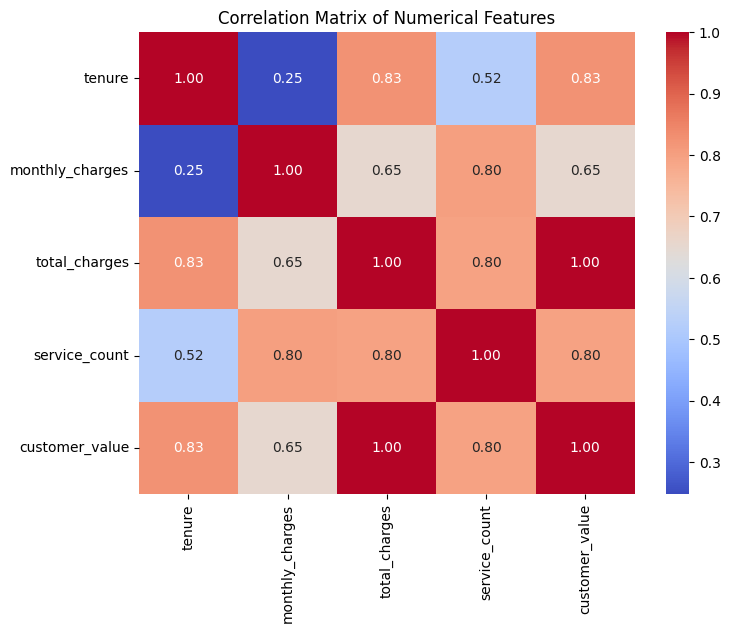

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Features")

plt.show()

#### Key Findings

- `customer_value` shows a perfect correlation (1.00) with `total_charges`.
- Since `customer_value` is an engineered approximation of the customer's monetary contribution, while `total_charges` is an original feature from the dataset, we decided to retain `total_charges` and remove `customer_value`.
- The remaining numerical variables present moderate to strong correlations, but each captures different aspects of customer behaviour and will be retained for modeling.

In [17]:
# Remove highly redundant feature
df.drop(columns=["customer_value"], inplace=True)

In [18]:
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

target = "churn_flag"

numerical_features = [col for col in numerical_columns if col != target]
categorical_features = df.select_dtypes(include=["object"]).columns.tolist()

C:\Users\estef\AppData\Local\Temp\ipykernel_28180\4032679972.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(include=["object"]).columns.tolist()


## 4. Define Features and Target (Define X and Y)

Before applying preprocessing techniques, we separate the predictors (X) from the target variable (y).

This ensures that all transformations are applied only to the input features and prevents data leakage.

In [19]:
target = "churn_flag"

X = df.drop(columns=[target])
y = df[target]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (7043, 25)
Target shape: (7043,)


In [20]:
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['tenure', 'monthly_charges', 'total_charges', 'service_count']

Categorical features:
['gender', 'senior_citizen', 'partner', 'dependents', 'phone_service', 'multiple_lines', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing', 'payment_method', 'tenure_group', 'has_internet_service', 'has_fiber_optic', 'has_automatic_payment', 'high_monthly_charges']


C:\Users\estef\AppData\Local\Temp\ipykernel_28180\1998881318.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


In [21]:
# Remove redundant engineered features

redundant_features = [
    "has_fiber_optic"
]

X = X.drop(columns=redundant_features)

print("Removed redundant features:", redundant_features)
print("New shape:", X.shape)

Removed redundant features: ['has_fiber_optic']
New shape: (7043, 24)


In [22]:
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print(categorical_features)

['gender', 'senior_citizen', 'partner', 'dependents', 'phone_service', 'multiple_lines', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing', 'payment_method', 'tenure_group', 'has_internet_service', 'has_automatic_payment', 'high_monthly_charges']


C:\Users\estef\AppData\Local\Temp\ipykernel_28180\728782784.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


### Separate binary vs multi-category features

In [23]:
binary_features = []
multi_category_features = []

for col in categorical_features:

    if X[col].nunique() == 2:
        binary_features.append(col)

    else:
        multi_category_features.append(col)

print("Binary features")
print(binary_features)

print("\nMulti-category features")
print(multi_category_features)

Binary features
['gender', 'senior_citizen', 'partner', 'dependents', 'phone_service', 'multiple_lines', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'paperless_billing', 'has_internet_service', 'has_automatic_payment', 'high_monthly_charges']

Multi-category features
['internet_service', 'contract', 'payment_method', 'tenure_group']


## 5. Train-Test Split

The dataset is divided into training and testing sets before fitting any preprocessing transformers.

This avoids information leakage from the test set into the training process.

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5634, 24)
X_test : (1409, 24)
y_train: (5634,)
y_test : (1409,)


The categorical features were divided into binary and multi-category variables to apply the most appropriate encoding strategy in the next steps.

## 6. Class Balance Check

Before training the classification models, we examine the distribution of the target variable in the training set.

A strong class imbalance may cause the models to favor the majority class and perform poorly when identifying customers who churn.

In [25]:
class_balance = pd.DataFrame({
    "Count": y_train.value_counts().sort_index(),
    "Percentage": (
        y_train.value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    )
})

class_balance.index = ["No Churn (0)", "Churn (1)"]

class_balance

,Count,Percentage
No Churn (0),4139,73.46
Churn (1),1495,26.54


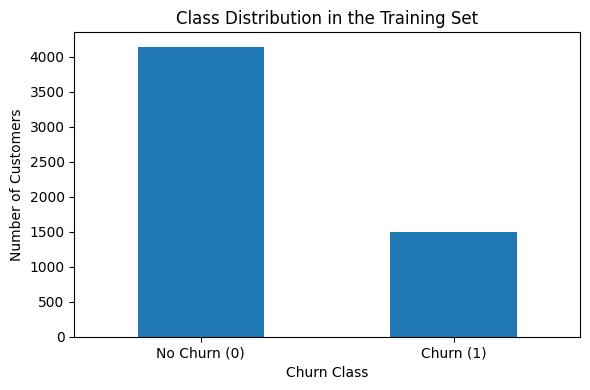

In [26]:
plt.figure(figsize=(6, 4))

y_train.value_counts().sort_index().plot(kind="bar")

plt.title("Class Distribution in the Training Set")
plt.xlabel("Churn Class")
plt.ylabel("Number of Customers")
plt.xticks(
    ticks=[0, 1],
    labels=["No Churn (0)", "Churn (1)"],
    rotation=0
)

plt.tight_layout()
plt.show()

### Class Balance Summary

The training set shows a moderate class imbalance, with approximately **73% non-churn customers** and **27% churn customers**.

Although the minority class is underrepresented, the imbalance is not severe enough to justify applying oversampling or undersampling techniques at this stage.

The baseline models will therefore be trained using the original data distribution.

Model performance will be evaluated using **Recall**, **F1-score**, and **ROC-AUC**, which are more informative than Accuracy for imbalanced classification problems.

In [27]:
print(
    f"Majority / Minority ratio: "
    f"{class_balance['Count'].iloc[0] / class_balance['Count'].iloc[1]:.2f}:1"
)

Majority / Minority ratio: 2.77:1


## 7. One-Hot Encoding for categorical variables (no need for scaling since  they are mainly 1 - 0 in the right scale)

Categorical variables must be converted into numerical format before training Machine Learning models.

We apply One-Hot Encoding to all categorical features. For binary variables, `drop='if_binary'` avoids creating redundant columns.

In [28]:
from sklearn.preprocessing import OneHotEncoder

In [29]:
encoder = OneHotEncoder(
    drop="if_binary",
    handle_unknown="ignore",
    sparse_output=False
)

In [30]:
X_train_cat = encoder.fit_transform(X_train[categorical_features])
X_test_cat = encoder.transform(X_test[categorical_features])

In [31]:
encoded_feature_names = encoder.get_feature_names_out(categorical_features)

X_train_cat = pd.DataFrame(
    X_train_cat,
    columns=encoded_feature_names,
    index=X_train.index
)

X_test_cat = pd.DataFrame(
    X_test_cat,
    columns=encoded_feature_names,
    index=X_test.index
)

In [32]:
print("Encoded train shape:", X_train_cat.shape)
print("Encoded test shape:", X_test_cat.shape)

X_train_cat.head()

Encoded train shape: (5634, 31)
Encoded test shape: (1409, 31)


,gender_Male,senior_citizen_Yes,partner_Yes,dependents_Yes,phone_service_Yes,multiple_lines_Yes,internet_service_DSL,internet_service_Fiber optic,internet_service_No,online_security_Yes,...,payment_method_Electronic check,payment_method_Mailed check,tenure_group_0_12_months,tenure_group_13_24_months,tenure_group_25_48_months,tenure_group_49_plus_months,tenure_group_new_0_months,has_internet_service_Yes,has_automatic_payment_Yes,high_monthly_charges_Yes
3738,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3151,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
4860,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3867,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0
3810,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


## 8. Scaling for numerical variables (they have difedifferentrent scales)

Numerical variables are standardized so they share a similar scale.

The scaler is fitted only on the training set and then applied to both training and test data to avoid data leakage.

In [33]:
from sklearn.preprocessing import StandardScaler

In [34]:
scaler = StandardScaler()

X_train_num = scaler.fit_transform(X_train[numerical_features])
X_test_num = scaler.transform(X_test[numerical_features])

In [35]:
X_train_num = pd.DataFrame(
    X_train_num,
    columns=numerical_features,
    index=X_train.index
)

X_test_num = pd.DataFrame(
    X_test_num,
    columns=numerical_features,
    index=X_test.index
)

In [36]:
print("Scaled train shape:", X_train_num.shape)
print("Scaled test shape:", X_test_num.shape)

X_train_num.head()

Scaled train shape: (5634, 4)
Scaled test shape: (1409, 4)


,tenure,monthly_charges,total_charges,service_count
3738,0.102371,-0.521976,-0.262257,-0.184954
3151,-0.711743,0.337478,-0.503635,-0.667823
4860,-0.793155,-0.809013,-0.749883,-0.184954
3867,-0.263980,0.284384,-0.172722,0.780784
3810,-1.281624,-0.676279,-0.989374,-1.150692


### Combine numerical and encoded categorical features

After scaling the numerical variables and encoding the categorical variables, we combine both parts into final training and testing datasets for Machine Learning models.

In [37]:
X_train_processed = pd.concat(
    [X_train_num, X_train_cat],
    axis=1
)

X_test_processed = pd.concat(
    [X_test_num, X_test_cat],
    axis=1
)

print("Final X_train shape:", X_train_processed.shape)
print("Final X_test shape:", X_test_processed.shape)

Final X_train shape: (5634, 35)
Final X_test shape: (1409, 35)


In [38]:
X_train_processed.head()

,tenure,monthly_charges,total_charges,service_count,gender_Male,senior_citizen_Yes,partner_Yes,dependents_Yes,phone_service_Yes,multiple_lines_Yes,...,payment_method_Electronic check,payment_method_Mailed check,tenure_group_0_12_months,tenure_group_13_24_months,tenure_group_25_48_months,tenure_group_49_plus_months,tenure_group_new_0_months,has_internet_service_Yes,has_automatic_payment_Yes,high_monthly_charges_Yes
3738,0.102371,-0.521976,-0.262257,-0.184954,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3151,-0.711743,0.337478,-0.503635,-0.667823,1.0,0.0,1.0,1.0,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
4860,-0.793155,-0.809013,-0.749883,-0.184954,1.0,0.0,1.0,1.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3867,-0.263980,0.284384,-0.172722,0.780784,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0
3810,-1.281624,-0.676279,-0.989374,-1.150692,1.0,0.0,1.0,1.0,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


## 9. Baseline model: Logistic Regression

We start with Logistic Regression because:

- It is a simple and interpretable classification algorithm.
- It provides a good performance baseline.
- It helps us compare more complex models later, such as Decision Trees and Random Forests.

In [39]:
from sklearn.linear_model import LogisticRegression

In [40]:
log_reg = LogisticRegression(
    random_state=42,
    max_iter=1000
)

In [41]:
#Start training

log_reg.fit(
    X_train_processed,
    y_train
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [42]:
print(log_reg)

LogisticRegression(max_iter=1000, random_state=42)


### Understanding the trained Logistic Regression model

Before making predictions, we inspected what the model learned from the training data.

In [43]:
print("Classes:", log_reg.classes_)

Classes: [0 1]


In [44]:
print("Number of features:", len(log_reg.coef_[0]))

Number of features: 35


In [45]:
coefficients = pd.DataFrame({
    "Feature": X_train_processed.columns,
    "Coefficient": log_reg.coef_[0]
})

coefficients.head()

,Feature,Coefficient
0,tenure,-1.144690
1,monthly_charges,-0.253068
2,total_charges,0.202757
3,service_count,0.374007
4,gender_Male,0.019425


In [46]:
coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

coefficients.head(10)

,Feature,Coefficient
11,internet_service_Fiber optic,0.771112
19,contract_Month-to-month,0.516875
30,tenure_group_49_plus_months,0.445688
32,has_internet_service_Yes,0.389947
22,paperless_billing_Yes,0.380112
3,service_count,0.374007
9,multiple_lines_Yes,0.213097
2,total_charges,0.202757
17,streaming_tv_Yes,0.181972
18,streaming_movies_Yes,0.178341


In [47]:
coefficients.tail(10)

,Feature,Coefficient
26,payment_method_Mailed check,-0.333404
28,tenure_group_13_24_months,-0.368750
10,internet_service_DSL,-0.381165
16,tech_support_Yes,-0.465638
8,phone_service_Yes,-0.513705
13,online_security_Yes,-0.523120
31,tenure_group_new_0_months,-0.571493
21,contract_Two year,-0.939195
12,internet_service_No,-1.017447
0,tenure,-1.144690


### Most influential features

The coefficients indicate how each feature influences the probability of customer churn.

- Positive values push predictions toward Churn = Yes.
- Negative values push predictions toward Churn = No.

In [48]:
import matplotlib.pyplot as plt

In [49]:
# Top positive and negative coefficients

top_positive = coefficients.head(10)
top_negative = coefficients.tail(10)

plot_df = pd.concat([top_negative, top_positive])

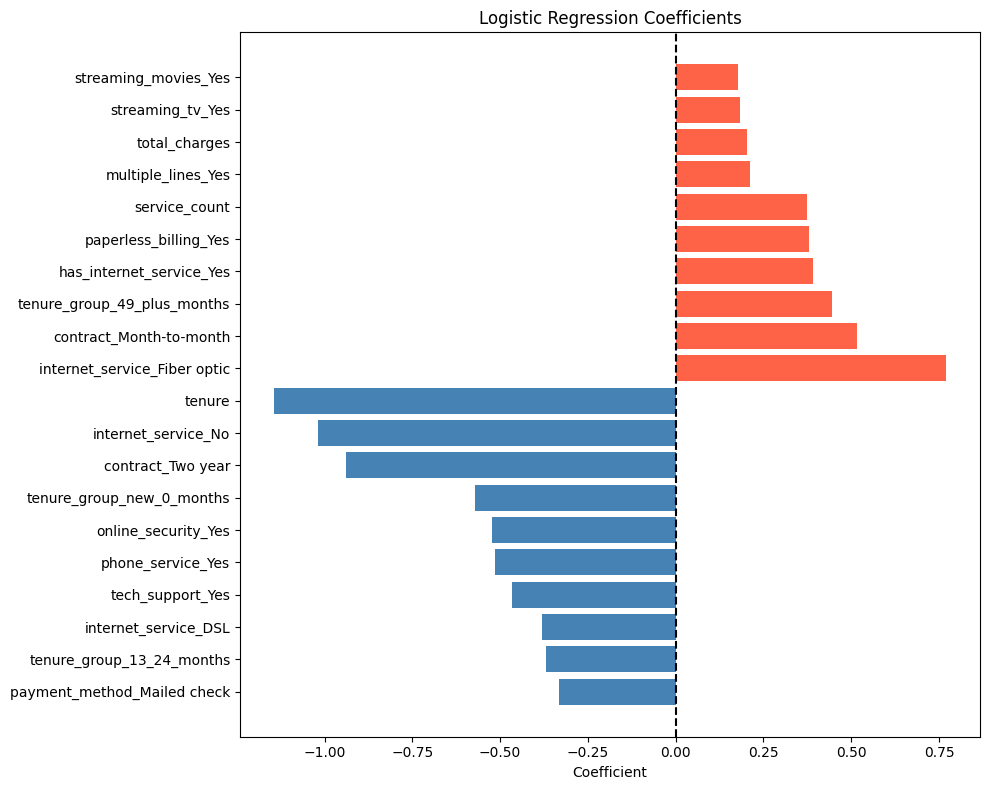

In [50]:
plt.figure(figsize=(10,8))

colors = [
    "tomato" if coef > 0 else "steelblue"
    for coef in plot_df["Coefficient"]
]

plt.barh(
    plot_df["Feature"],
    plot_df["Coefficient"],
    color=colors
)

plt.axvline(
    x=0,
    color="black",
    linestyle="--"
)

plt.title("Logistic Regression Coefficients")

plt.xlabel("Coefficient")

plt.tight_layout()

plt.show()

### Logistic Regression Evaluation

Now that the model has been trained, we evaluate its predictive performance on the unseen test dataset.

We first generate class predictions and prediction probabilities.

In [51]:
# Generate predictions

y_pred = log_reg.predict(X_test_processed)

# Generate prediction probabilities

y_pred_proba = log_reg.predict_proba(X_test_processed)[:,1]

In [52]:
print("First 10 predictions:")
print(y_pred[:10])

print("\nFirst 10 probabilities:")
print(y_pred_proba[:10])

First 10 predictions:
[0 1 0 0 0 1 0 0 0 0]

First 10 probabilities:
[0.04271843 0.73654572 0.05150915 0.32738435 0.02304368 0.54620285
 0.38169586 0.10873005 0.00474211 0.31529372]


### Confusion Matrix

The confusion matrix summarizes the model's predictions by comparing the predicted classes with the actual classes.

It allows us to identify correct predictions and different types of classification errors.

In [53]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [54]:
cm = confusion_matrix(
    y_test,
    y_pred
)

cm

array([[932, 103],
       [181, 193]])

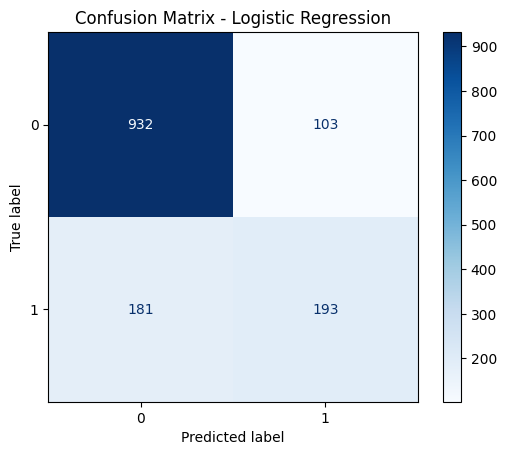

In [55]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=log_reg.classes_
)

disp.plot(
    cmap="Blues"
)

plt.title("Confusion Matrix - Logistic Regression")

plt.show()

The confusion matrix shows that the Logistic Regression model correctly classified most customers who did not churn (True Negatives = 932).

However, it failed to identify 181 customers who actually churned (False Negatives), while correctly detecting 193 churning customers (True Positives).

Since missing a churning customer may represent a lost business opportunity, reducing False Negatives will be an important objective when evaluating more advanced models such as Decision Tree and Random Forest.

### Classification Metrics

To evaluate the Logistic Regression model, we use several classification metrics.

Since each metric measures a different aspect of model performance, they should be interpreted together rather than individually.

In [56]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

In [57]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred) #Balance between precision and Recall

roc_auc = roc_auc_score(y_test, y_pred_proba)

In [58]:
#Show results in a table
log_reg_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

log_reg_metrics

,Metric,Value
0,Accuracy,0.798439
1,Precision,0.652027
2,Recall,0.516043
3,F1-score,0.576119
4,ROC-AUC,0.842280


In [59]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



### Logistic Regression Performance

The baseline Logistic Regression model achieved an accuracy of approximately **80%**, indicating that most customers were correctly classified.

However, the model identified only **51.6% of the customers who actually churned (Recall)**, meaning that a considerable number of churning customers were missed.

The **Precision (65.2%)** indicates that around two out of every three customers predicted as churners actually left the company.

Finally, the model achieved a **ROC-AUC of 0.842**, showing a good ability to distinguish between customers who churn and those who remain.

Overall, Logistic Regression provides a solid and interpretable baseline, but more flexible models may improve the detection of churning customers.

### ROC Curve

The ROC Curve evaluates the model's ability to distinguish between customers who churn and those who remain.

The Area Under the Curve (ROC-AUC) summarizes this performance into a single metric.

In [60]:
from sklearn.metrics import RocCurveDisplay

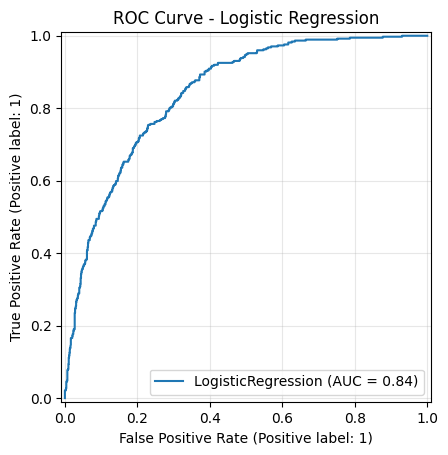

In [61]:
RocCurveDisplay.from_estimator(
    log_reg,
    X_test_processed,
    y_test
)

plt.title("ROC Curve - Logistic Regression")

plt.grid(alpha=0.3)

plt.show()

The ROC Curve evaluates how well the Logistic Regression model distinguishes between customers who churn and customers who remain.

The model achieved an **AUC score of 0.84**, which indicates a good ability to separate both classes.

However, since the confusion matrix and recall score showed that the model still misses a considerable number of actual churners, the next step is to compare this baseline with more flexible models such as Decision Tree and Random Forest.
Función reutilizable

### Reusable Evaluation Function

In [62]:
def evaluate_classification_model(model, X_test, y_test, model_name):
    """
    Evaluates a classification model using key classification metrics.
    """
    
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    results = pd.DataFrame({
        "Model": [model_name],
        "Accuracy": [accuracy_score(y_test, y_pred)],
        "Precision": [precision_score(y_test, y_pred)],
        "Recall": [recall_score(y_test, y_pred)],
        "F1-score": [f1_score(y_test, y_pred)],
        "ROC-AUC": [roc_auc_score(y_test, y_pred_proba)]
    })
    
    return results

In [63]:
#Tes with Logistic Regression

log_reg_results = evaluate_classification_model(
    log_reg,
    X_test_processed,
    y_test,
    "Logistic Regression"
)

log_reg_results.round(3)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.798,0.652,0.516,0.576,0.842


## 8. Compare with Decision Tree (Baseline)

We first train an unrestricted Decision Tree to observe its initial performance and determine whether the model overfits the training data.

Unlike Logistic Regression, Decision Trees can capture non-linear relationships and interactions between features.

In [64]:
from sklearn.tree import DecisionTreeClassifier

In [65]:
baseline_tree = DecisionTreeClassifier(
    random_state=42
)

In [66]:
baseline_tree.fit(
    X_train_processed,
    y_train
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

### Evaluate Decision Tree

In [67]:
baseline_tree_results = evaluate_classification_model(
    baseline_tree,
    X_test_processed,
    y_test,
    "Decision Tree - Unrestricted"
)

baseline_tree_results.round(3)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Decision Tree - Unrestricted,0.732,0.496,0.505,0.501,0.659


### Baseline Decision Tree: Overfitting Check

We compare the unrestricted tree's training and test accuracy to assess whether the model is overfitting.

A large gap between both scores suggests that the model is memorizing the training data and does not generalize well to unseen customers.

In [68]:
baseline_train_accuracy = baseline_tree.score(
    X_train_processed,
    y_train
)

baseline_test_accuracy = baseline_tree.score(
    X_test_processed,
    y_test
)

baseline_accuracy_gap = (
    baseline_train_accuracy
    - baseline_test_accuracy
)

print(f"Baseline Training Accuracy: {baseline_train_accuracy:.3f}")
print(f"Baseline Test Accuracy: {baseline_test_accuracy:.3f}")
print(f"Baseline Accuracy Gap: {baseline_accuracy_gap:.3f}")

Baseline Training Accuracy: 0.998
Baseline Test Accuracy: 0.732
Baseline Accuracy Gap: 0.266


### Decision Tree Hyperparameter Tuning

Before selecting the final Decision Tree model, we test different values of `max_depth`.

The goal is to find a tree that performs well without becoming too complex and overfitting the training data.

In [69]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

tree_param_grid = {
    "max_depth": [2, 3, 4, 5, 6, 8, 10, None]
}

tree_grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(
        random_state=42
    ),
    param_grid=tree_param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

tree_grid_search.fit(
    X_train_processed,
    y_train
)

print("Best parameters:")
print(tree_grid_search.best_params_)

print("\nBest cross-validation ROC-AUC:")
print(round(tree_grid_search.best_score_, 3))

Best parameters:
{'max_depth': 4}

Best cross-validation ROC-AUC:
0.827


In [70]:
decision_tree = tree_grid_search.best_estimator_

In [71]:
decision_tree_results = evaluate_classification_model(
    decision_tree,
    X_test_processed,
    y_test,
    "Decision Tree"
)

decision_tree_results.round(3)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Decision Tree,0.793,0.653,0.473,0.549,0.831


In [72]:
tree_cv_results = pd.DataFrame(
    tree_grid_search.cv_results_
)

tree_depth_results = tree_cv_results[
    [
        "param_max_depth",
        "mean_test_score",
        "std_test_score"
    ]
].copy()

tree_depth_results = tree_depth_results.rename(
    columns={
        "param_max_depth": "max_depth",
        "mean_test_score": "mean_cv_roc_auc",
        "std_test_score": "std_cv_roc_auc"
    }
)

tree_depth_results.round(3)

,max_depth,mean_cv_roc_auc,std_cv_roc_auc
0,2,0.792,0.017
1,3,0.819,0.010
2,4,0.827,0.011
3,5,0.827,0.012
4,6,0.821,0.009
5,8,0.790,0.012
6,10,0.747,0.008
7,None,0.651,0.008


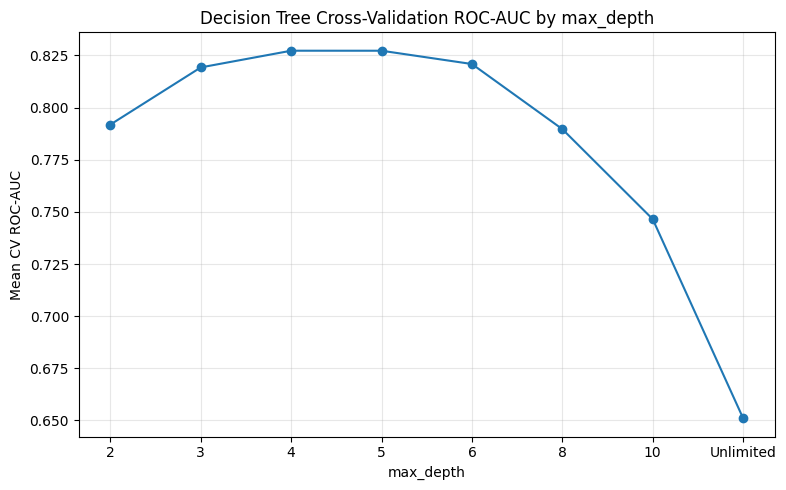

In [101]:
plot_tree_results = tree_depth_results.copy()

plot_tree_results["max_depth_label"] = (
    plot_tree_results["max_depth"]
    .apply(
        lambda value: (
            "Unlimited"
            if value is None or pd.isna(value)
            else str(int(value))
        )
    )
)

plt.figure(figsize=(8, 5))

plt.plot(
    plot_tree_results["max_depth_label"],
    plot_tree_results["mean_cv_roc_auc"],
    marker="o"
)

plt.title("Decision Tree Cross-Validation ROC-AUC by max_depth")
plt.xlabel("max_depth")
plt.ylabel("Mean CV ROC-AUC")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Based on the cross-validation results, the Decision Tree configuration with the highest mean ROC-AUC was selected as the final model. The selected model was then evaluated once on the untouched test dataset.

## Final Decision Tree Model

Based on the cross-validation results, the Decision Tree configuration with the highest mean ROC-AUC was selected as the final model. This model was then evaluated once on the untouched test dataset to estimate its generalization performance.

In [102]:
decision_tree = tree_grid_search.best_estimator_

In [103]:
decision_tree_results = evaluate_classification_model(
    decision_tree,
    X_test_processed,
    y_test,
    "Decision Tree"
)

decision_tree_results.round(3)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Decision Tree,0.793,0.653,0.473,0.549,0.831


### Final Decision Tree: Overfitting Check

After selecting `max_depth=5`, we compare the final model's training and test accuracy to verify whether limiting the depth reduced overfitting.

In [75]:
final_tree_train_accuracy = decision_tree.score(
    X_train_processed,
    y_train
)

final_tree_test_accuracy = decision_tree.score(
    X_test_processed,
    y_test
)

final_tree_accuracy_gap = (
    final_tree_train_accuracy
    - final_tree_test_accuracy
)

tree_fit_comparison = pd.DataFrame({
    "Model": [
        "Unrestricted Decision Tree",
        "Decision Tree (max_depth=5)"
    ],
    "Training Accuracy": [
        baseline_train_accuracy,
        final_tree_train_accuracy
    ],
    "Test Accuracy": [
        baseline_test_accuracy,
        final_tree_test_accuracy
    ],
    "Accuracy Gap": [
        baseline_accuracy_gap,
        final_tree_accuracy_gap
    ]
})

tree_fit_comparison.round(3)

,Model,Training Accuracy,Test Accuracy,Accuracy Gap
0,Unrestricted Decision Tree,0.998,0.732,0.266
1,Decision Tree (max_depth=5),0.804,0.799,0.005


### Compared vs Logistic Regression

In [76]:
comparison = pd.concat(
    [
        log_reg_results,
        decision_tree_results
    ],
    ignore_index=True
)

comparison.round(3)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.798,0.652,0.516,0.576,0.842
1,Decision Tree,0.799,0.632,0.583,0.606,0.834


Both models achieved very similar overall accuracy (approximately 80%).

The tuned Decision Tree improved Recall and F1-score, meaning it identified a higher proportion of customers who actually churned.

On the other hand, Logistic Regression achieved slightly higher Precision and ROC-AUC, while remaining easier to interpret.

At this stage, the Decision Tree is a stronger candidate when the business priority is detecting more customers at risk of churn. However, Random Forest will also be evaluated before selecting the final model.

## 9. Compare with Random Forest

In [77]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    random_state=42
)

random_forest.fit(
    X_train_processed,
    y_train
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [78]:
random_forest_results = evaluate_classification_model(
    random_forest,
    X_test_processed,
    y_test,
    "Random Forest"
)

random_forest_results.round(3)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Random Forest,0.779,0.608,0.476,0.534,0.824


In [79]:
rf_train_accuracy = random_forest.score(
    X_train_processed,
    y_train
)

rf_test_accuracy = random_forest.score(
    X_test_processed,
    y_test
)

rf_accuracy_gap = (
    rf_train_accuracy - rf_test_accuracy
)

rf_overfitting_check = pd.DataFrame({
    "Model": ["Random Forest"],
    "Training Accuracy": [rf_train_accuracy],
    "Test Accuracy": [rf_test_accuracy],
    "Accuracy Gap": [rf_accuracy_gap]
})

rf_overfitting_check.round(3)

,Model,Training Accuracy,Test Accuracy,Accuracy Gap
0,Random Forest,0.998,0.779,0.219


### Random Forest Hyperparameter Tuning

The baseline Random Forest shows strong overfitting, with almost perfect training accuracy but considerably lower test accuracy. We use GridSearchCV to find a simpler model that generalizes better to unseen customers.

In [80]:
from sklearn.model_selection import GridSearchCV

rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 8, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

rf_grid_search = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42
    ),
    param_grid=rf_param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=1
)

rf_grid_search.fit(
    X_train_processed,
    y_train
)

Fitting 5 folds for each of 144 candidates, totalling 720 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 8, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_g

In [81]:
print("Best parameters:")
print(rf_grid_search.best_params_)

print("\nBest cross-validation ROC-AUC:")
print(round(rf_grid_search.best_score_, 3))

Best parameters:
{'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 200}

Best cross-validation ROC-AUC:
0.846


In [82]:
best_random_forest = rf_grid_search.best_estimator_

In [83]:
best_rf_results = evaluate_classification_model(
    best_random_forest,
    X_test_processed,
    y_test,
    "Random Forest Tuned"
)

best_rf_results.round(3)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Random Forest Tuned,0.803,0.671,0.508,0.578,0.846


In [84]:
best_rf_train_accuracy = best_random_forest.score(
    X_train_processed,
    y_train
)

best_rf_test_accuracy = best_random_forest.score(
    X_test_processed,
    y_test
)

best_rf_accuracy_gap = (
    best_rf_train_accuracy - best_rf_test_accuracy
)

rf_fit_comparison = pd.DataFrame({
    "Model": [
        "Random Forest Baseline",
        "Random Forest Tuned"
    ],
    "Training Accuracy": [
        rf_train_accuracy,
        best_rf_train_accuracy
    ],
    "Test Accuracy": [
        rf_test_accuracy,
        best_rf_test_accuracy
    ],
    "Accuracy Gap": [
        rf_accuracy_gap,
        best_rf_accuracy_gap
    ]
})

rf_fit_comparison.round(3)

,Model,Training Accuracy,Test Accuracy,Accuracy Gap
0,Random Forest Baseline,0.998,0.779,0.219
1,Random Forest Tuned,0.824,0.803,0.021


In [85]:
rf_model_comparison = pd.concat(
    [
        random_forest_results,
        best_rf_results
    ],
    ignore_index=True
)

rf_model_comparison.round(3)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Random Forest,0.779,0.608,0.476,0.534,0.824
1,Random Forest Tuned,0.803,0.671,0.508,0.578,0.846


The baseline Random Forest showed substantial overfitting, with a training accuracy of 0.998 compared with a test accuracy of 0.779.

After hyperparameter tuning, the training-test accuracy gap decreased from 0.219 to 0.021, indicating considerably better generalization. The tuned model also improved all test metrics, including Accuracy, Precision, Recall, F1-score and ROC-AUC.

The tuned Random Forest achieved the highest ROC-AUC so far at 0.846, making it a strong candidate for the final model. However, the final selection should also consider Recall, since identifying customers at risk of churn is an important business priority.

## 10. Model Comparison

In [86]:
final_model_comparison = pd.concat(
    [
        log_reg_results,
        decision_tree_results,
        best_rf_results
    ],
    ignore_index=True
)

final_model_comparison.round(3)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.798,0.652,0.516,0.576,0.842
1,Decision Tree,0.799,0.632,0.583,0.606,0.834
2,Random Forest Tuned,0.803,0.671,0.508,0.578,0.846


In [87]:
final_model_comparison.round(3)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.798,0.652,0.516,0.576,0.842
1,Decision Tree,0.799,0.632,0.583,0.606,0.834
2,Random Forest Tuned,0.803,0.671,0.508,0.578,0.846


### ROC-AUC Comparison

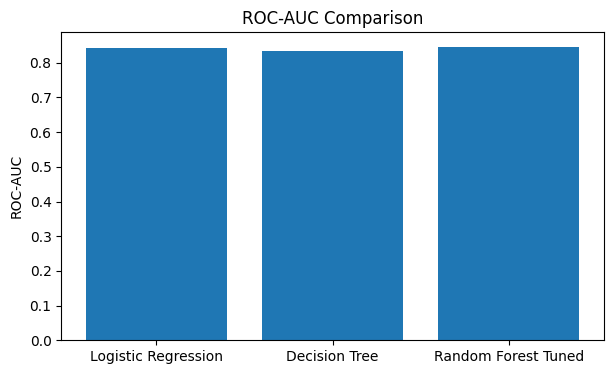

In [88]:
plt.figure(figsize=(7,4))

plt.bar(
    final_model_comparison["Model"],
    final_model_comparison["ROC-AUC"]
)

plt.title("ROC-AUC Comparison")
plt.ylabel("ROC-AUC")

plt.show()

### Recall Comparison

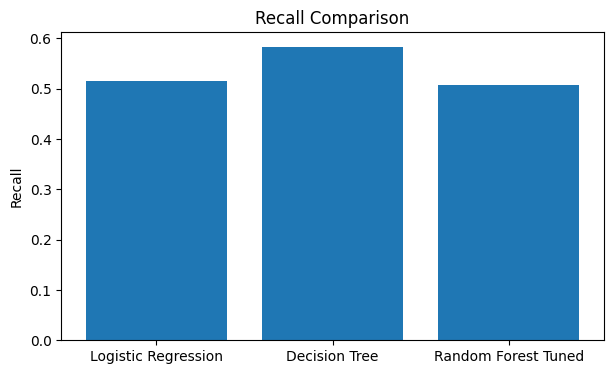

In [89]:
plt.figure(figsize=(7,4))

plt.bar(
    final_model_comparison["Model"],
    final_model_comparison["Recall"]
)

plt.title("Recall Comparison")
plt.ylabel("Recall")

plt.show()

The three models achieved similar overall Accuracy, all close to 80%.

The tuned Random Forest achieved the highest Accuracy (0.803), Precision (0.671) and ROC-AUC (0.846), while also showing substantially better generalization after hyperparameter tuning.

The Decision Tree obtained the highest Recall (0.583), making it more effective at identifying customers who are likely to churn.

Considering the balance between predictive performance, generalization and ROC-AUC, the tuned Random Forest was selected as the final model for the next stage of the analysis.

## 11. Balancing (SMOTE)

The training data presents a moderate class imbalance, with approximately 73% non-churn customers and 27% churn customers.

To evaluate whether improving the representation of the minority class could help the final model detect more churn customers, we apply SMOTE only to the training dataset.

The test dataset is not balanced because it must preserve the original class distribution for an unbiased evaluation.

In [90]:
from imblearn.over_sampling import SMOTE

In [91]:
#!pip install imbalanced-learn

### Original Training Distribution

Before applying SMOTE, we confirm the original class distribution in the training dataset.

In [92]:
original_distribution = pd.DataFrame({
    "Count": y_train.value_counts().sort_index(),
    "Percentage": (
        y_train.value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    )
})

original_distribution.index = [
    "No Churn (0)",
    "Churn (1)"
]

original_distribution

,Count,Percentage
No Churn (0),4139,73.46
Churn (1),1495,26.54


### Apply SMOTE to the Training Set

SMOTE creates synthetic observations for the minority class by generating new examples based on similar existing customers.

It is applied only after the train-test split to prevent information from the test set leaking into the training process.

In [93]:
smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

print("Original training shape:", X_train_processed.shape)
print("Balanced training shape:", X_train_smote.shape)

Original training shape: (5634, 35)
Balanced training shape: (8278, 35)


### Balanced Training Distribution

After applying SMOTE, both classes contain the same number of training observations.

In [94]:
smote_distribution = pd.DataFrame({
    "Count": y_train_smote.value_counts().sort_index(),
    "Percentage": (
        y_train_smote.value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    )
})

smote_distribution.index = [
    "No Churn (0)",
    "Churn (1)"
]

smote_distribution

,Count,Percentage
No Churn (0),4139,50.0
Churn (1),4139,50.0


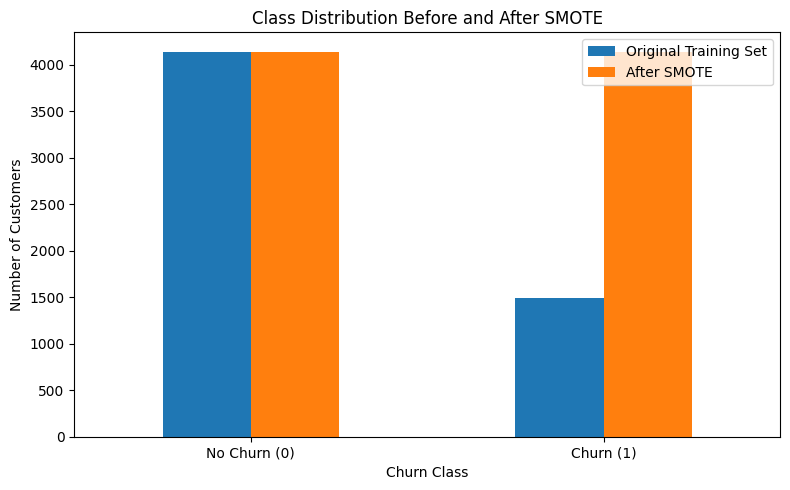

In [95]:
balance_comparison = pd.DataFrame({
    "Original Training Set": y_train.value_counts().sort_index(),
    "After SMOTE": y_train_smote.value_counts().sort_index()
})

balance_comparison.index = [
    "No Churn (0)",
    "Churn (1)"
]

balance_comparison.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Class Distribution Before and After SMOTE")
plt.xlabel("Churn Class")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### SMOTE Summary

SMOTE successfully balanced the training dataset by increasing the number of minority-class observations until both classes represented 50% of the training data.

Only the training set was resampled. The test set remains unchanged so that future model evaluation reflects the original customer distribution.

Once the best-performing baseline model has been selected, it will be retrained using `X_train_smote` and `y_train_smote`. Its performance will then be compared with the same model trained on the original data, focusing particularly on Recall, F1-score and the number of False Negatives.

## 12. Retrain Best Model(s)

In [96]:
rf_smote = RandomForestClassifier(
    **rf_grid_search.best_params_,
    random_state=42
)

rf_smote.fit(
    X_train_smote,
    y_train_smote
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap:

### Evaluate the SMOTE Model

In [97]:
rf_smote_results = evaluate_classification_model(
    rf_smote,
    X_test_processed,
    y_test,
    "Random Forest + SMOTE"
)

rf_smote_results.round(3)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Random Forest + SMOTE,0.767,0.544,0.751,0.631,0.844


## 13. Compare Before vs After

In [98]:
smote_comparison = pd.concat(
    [
        best_rf_results,
        rf_smote_results
    ],
    ignore_index=True
)

smote_comparison.round(3)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Random Forest Tuned,0.803,0.671,0.508,0.578,0.846
1,Random Forest + SMOTE,0.767,0.544,0.751,0.631,0.844


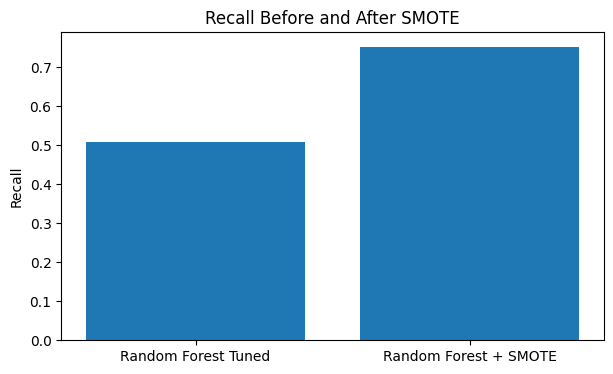

In [99]:
plt.figure(figsize=(7,4))

plt.bar(
    smote_comparison["Model"],
    smote_comparison["Recall"]
)

plt.title("Recall Before and After SMOTE")
plt.ylabel("Recall")

plt.show()

Although the overall Accuracy and Precision decreased after applying SMOTE, the model's ability to correctly identify customers who churned improved substantially.

Recall increased from 0.508 to 0.751, meaning the model now detects a much larger proportion of customers at risk of leaving.

The F1-score also improved, while ROC-AUC remained almost unchanged, indicating that the model maintained strong discriminative performance despite the balanced training data.

For churn prediction, where missing customers who are likely to leave can be more costly than contacting a few additional customers, the Random Forest trained with SMOTE provides a more suitable solution.

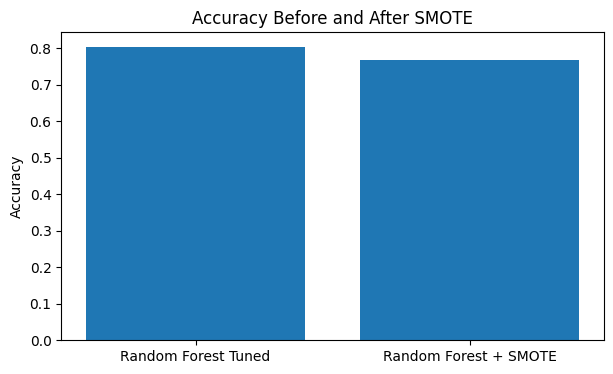

In [100]:
plt.figure(figsize=(7,4))

plt.bar(
    smote_comparison["Model"],
    smote_comparison["Accuracy"]
)

plt.title("Accuracy Before and After SMOTE")
plt.ylabel("Accuracy")

plt.show()

## Final Conclusions

Three classification models were evaluated to predict customer churn.

Logistic Regression provided a simple and interpretable baseline with competitive performance.

Decision Tree improved Recall, identifying more customers who were likely to churn, although it presented a higher risk of overfitting before tuning.

After hyperparameter tuning, Random Forest achieved the highest Accuracy, Precision and ROC-AUC while maintaining excellent generalization.

Finally, applying SMOTE substantially improved Recall from 0.508 to 0.751, allowing the model to identify many more customers at risk of churn.

Although Accuracy decreased slightly, the improvement in Recall and F1-score makes the Random Forest trained with SMOTE the most suitable model for churn prediction, where failing to identify customers who are likely to leave is more costly than contacting additional customers.